Tukaj bo izvajane vse analize in filtrirane kode za vzorce, ki jih iščemo; medtem pa bo pr.py bil pomozna knjiznica za osnove funkcije kot so nalaganje tsv-jev in šiščenje podatkovnih zbirk.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from data_utils import *
import sklearn

Koliko obnovljive energije uporabljajo po državah skozi desetletje do zdaj (heatmap prikaz)


Loaded estat_nrg_ind_ren in 0.021s - 3759 rows


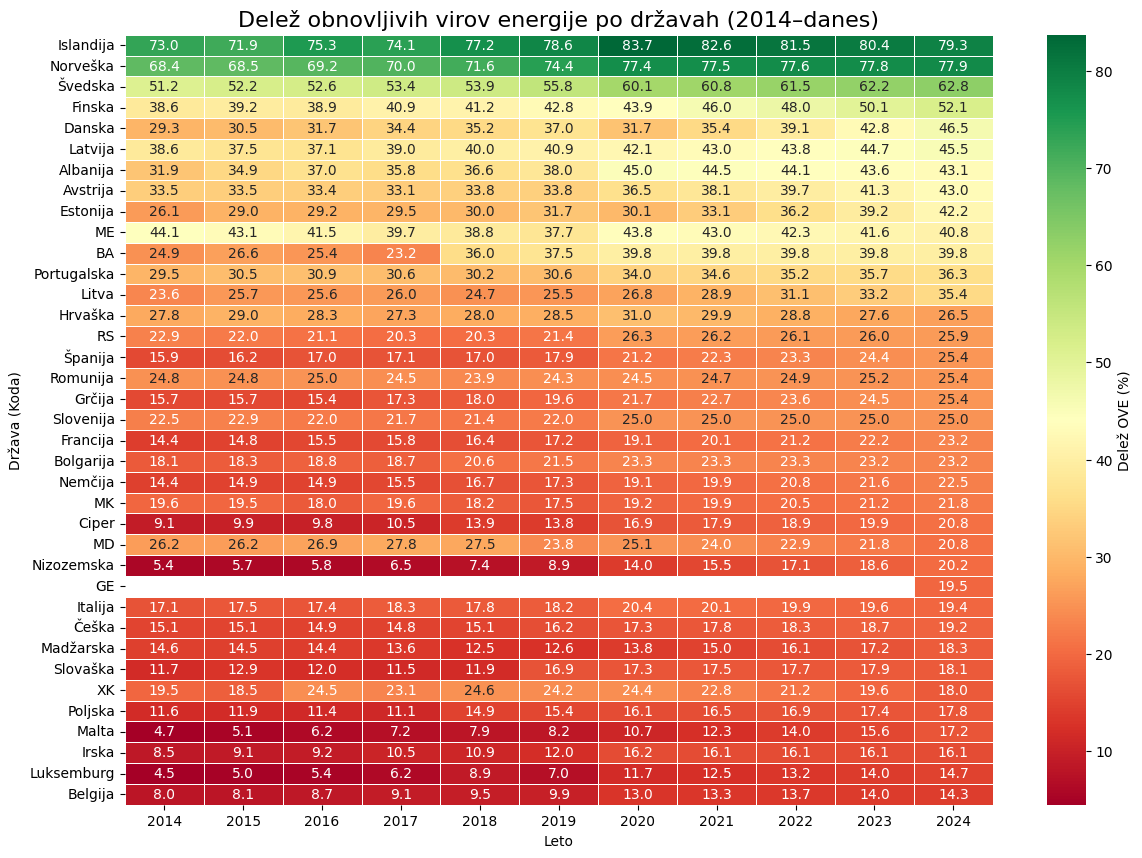

In [4]:
df_ren = share_of_renewables()
df_ren = add_country_names(df_ren)

df_filtered = df_ren[
    (df_ren['nrg_bal'] == 'REN') & 
    (df_ren['year'] >= 2014) &
    (df_ren['geo'].str.len() == 2)
]

pivot_df = df_filtered[df_filtered['nrg_bal'] == 'REN'].pivot(index='drzava', columns='year', values='value')
pivot_df = pivot_df.interpolate(axis=1)
pivot_df = pivot_df.sort_values(by=pivot_df.columns[-1], ascending=False)

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_df, 
            annot=True,
            fmt=".1f",
            cmap="RdYlGn",
            linewidths=.5, 
            cbar_kws={'label': 'Delež OVE (%)'})

plt.title('Delež obnovljivih virov energije po državah (2014–danes)', fontsize=16)
plt.xlabel('Leto')
plt.ylabel('Država (Koda)')
plt.show()

Preskoči GE: Ni dovolj podatkov.


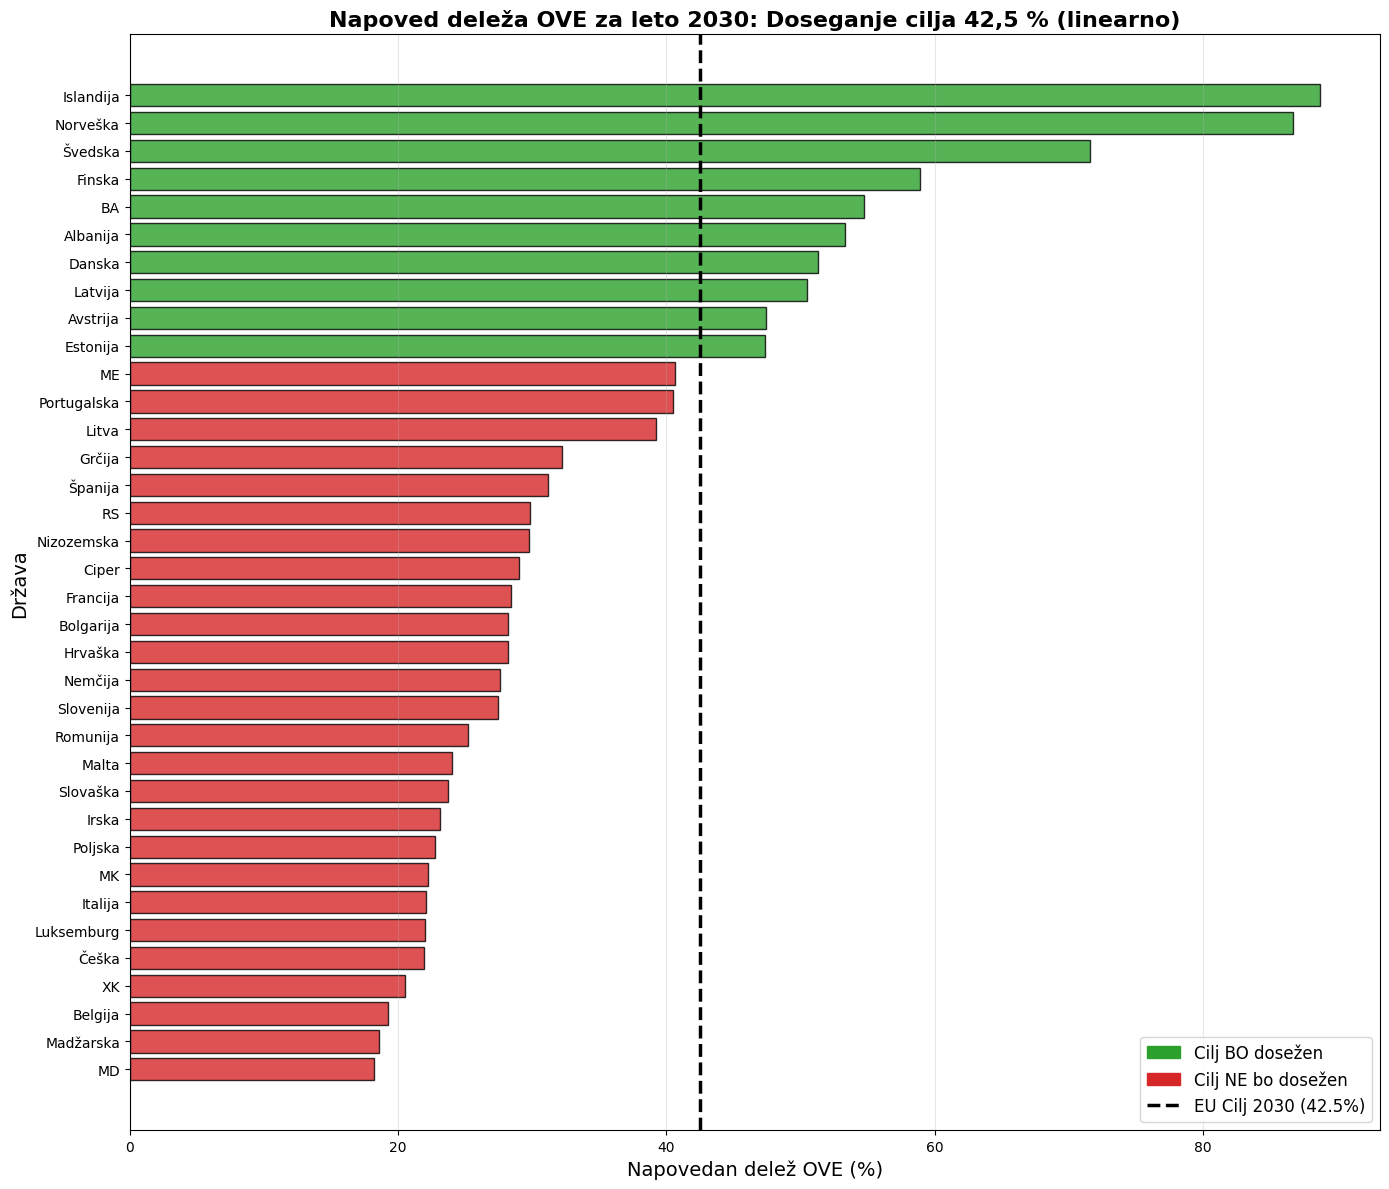

         drzava  zadnje_leto  napoved_2030  dosega_cilj
0     Islandija       79.332     88.743191         True
1      Norveška       77.932     86.730155         True
2       Švedska       62.846     71.548891         True
3        Finska       52.124     58.913336         True
10           BA       39.835     54.700400         True
6      Albanija       43.111     53.320364         True
4        Danska       46.461     51.316100         True
5       Latvija       45.535     50.456264         True
7      Avstrija       42.951     47.381464         True
8      Estonija       42.232     47.327000         True
9            ME       40.822     40.641945        False
11  Portugalska       36.319     40.501018        False
12        Litva       35.408     39.212373        False
17       Grčija       25.364     32.196582        False
15      Španija       25.417     31.159655        False
14           RS       25.862     29.844627        False
25   Nizozemska       20.180     29.774482      

In [41]:
from sklearn.linear_model import LinearRegression
import matplotlib.patches as mpatches

results = []

for country in pivot_df.index:
    temp_series = pivot_df.loc[country].dropna()
    if len(temp_series) < 2:
        print(f"Preskoči {country}: Ni dovolj podatkov.")
        continue
        
    y = temp_series.values
    X = np.array(temp_series.index).reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(X, y)
    pred_2030 = model.predict([[2030]])[0]
    
    results.append({
        'drzava': country, 
        'zadnje_leto': y[-1], 
        'napoved_2030': pred_2030
    })


df_pred = pd.DataFrame(results)
df_pred['dosega_cilj'] = df_pred['napoved_2030'] >= 42.5
df_pred = df_pred.sort_values(by='napoved_2030', ascending=False)
df_viz = df_pred.sort_values(by='napoved_2030', ascending=True)

colors = ['#2ca02c' if x else '#d62728' for x in df_viz['dosega_cilj']]

plt.figure(figsize=(14, 12))

bars = plt.barh(df_viz['drzava'], df_viz['napoved_2030'], color=colors, edgecolor='black', alpha=0.8)

plt.axvline(x=42.5, color='black', linestyle='--', linewidth=2.5, label='EU Cilj 2030 (42.5%)')
plt.title('Napoved deleža OVE za leto 2030: Doseganje cilja 42,5 % (linearno)', fontsize=16, fontweight='bold')
plt.xlabel('Napovedan delež OVE (%)', fontsize=14)
plt.ylabel('Država', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.3)

red_patch = mpatches.Patch(color='#d62728', label='Cilj NE bo dosežen')
green_patch = mpatches.Patch(color='#2ca02c', label='Cilj BO dosežen')
plt.legend(handles=[green_patch, red_patch, plt.gca().get_lines()[0]], loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

print(df_pred[['drzava', 'zadnje_leto', 'napoved_2030', 'dosega_cilj']])

Za izboljšanje napovedi smo namesto linearne regresije uporablili polinomsko regresijo (2. stopnje) ter regulirali z Ridge regresijo (α = 1).

Preskoči GE: Ni dovolj podatkov.


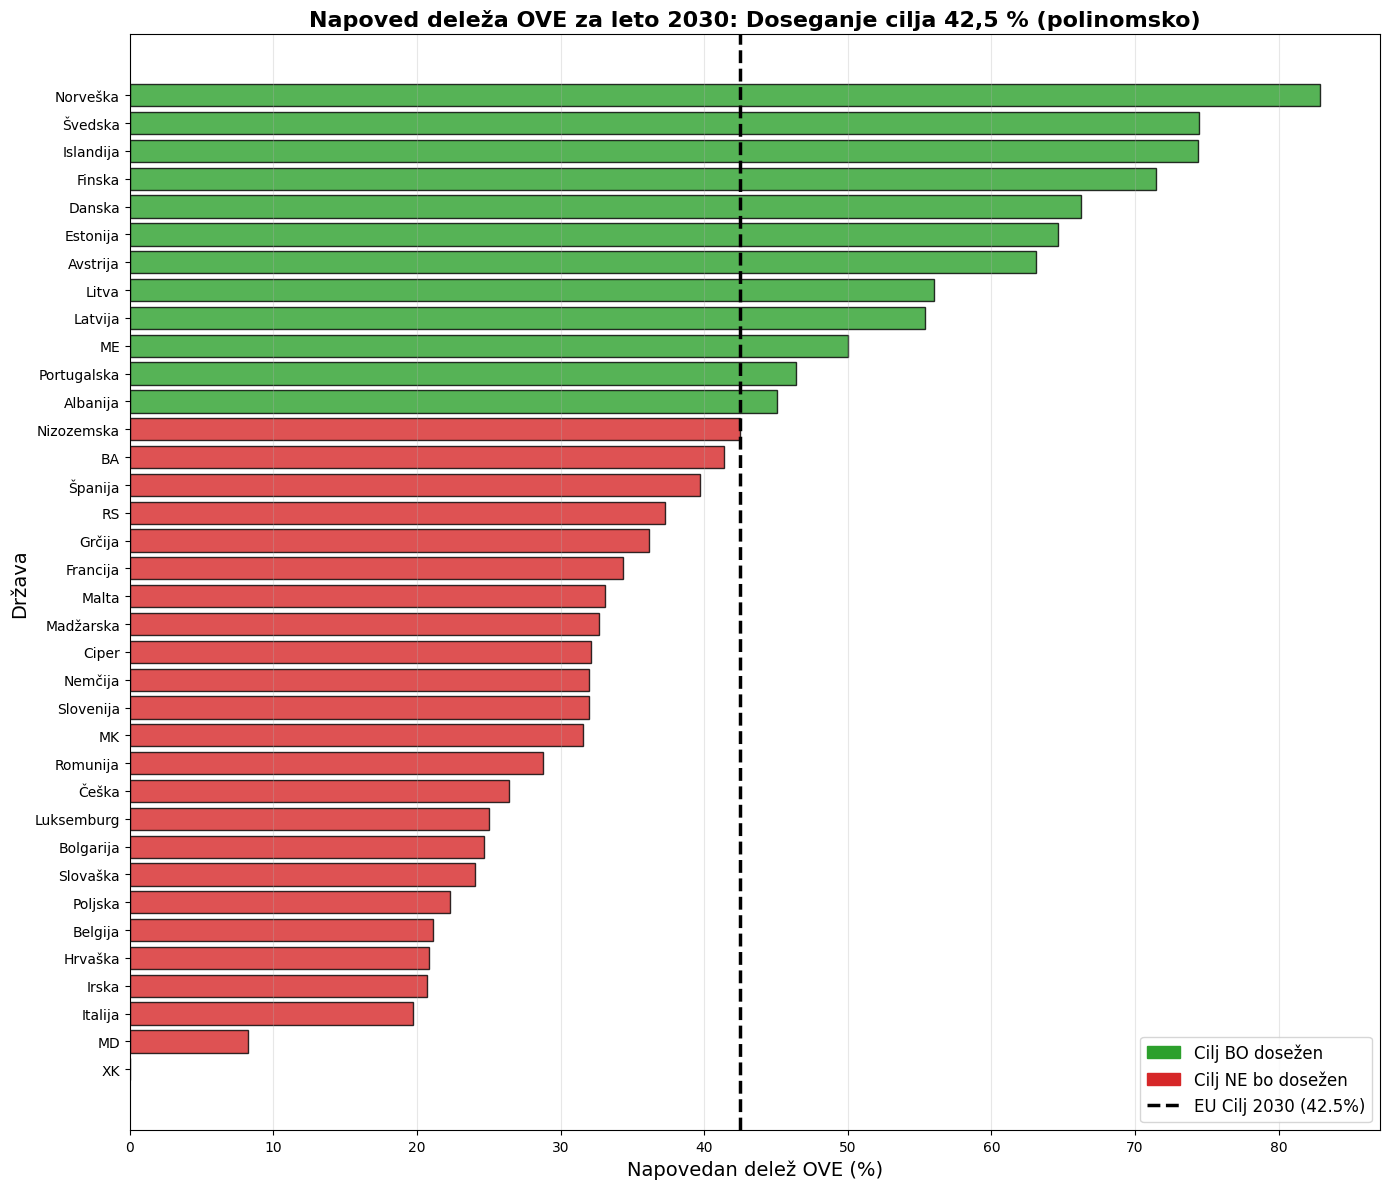

         drzava  zadnje_leto  napoved_2030  dosega_cilj
1      Norveška       77.932     82.913228         True
2       Švedska       62.846     74.451638         True
0     Islandija       79.332     74.403057         True
3        Finska       52.124     71.471552         True
4        Danska       46.461     66.238399         True
8      Estonija       42.232     64.612659         True
7      Avstrija       42.951     63.086561         True
12        Litva       35.408     56.026998         True
5       Latvija       45.535     55.355286         True
9            ME       40.822     50.034294         True
11  Portugalska       36.319     46.400727         True
6      Albanija       43.111     45.054818         True
25   Nizozemska       20.180     42.460319        False
10           BA       39.835     41.371860        False
15      Španija       25.417     39.689534        False
14           RS       25.862     37.304269        False
17       Grčija       25.364     36.164997      

In [40]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
import matplotlib.patches as mpatches

rezultati = []

for country in pivot_df.index:
    temp_series = pivot_df.loc[country].dropna()
    if len(temp_series) < 2:
        print(f"Preskoči {country}: Ni dovolj podatkov.")
        continue
        
    # Priprava podatkov za polinomsko regresijo
    y = temp_series.values
    zacetek = np.array(temp_series.index).min()
    X = (np.array(temp_series.index) - zacetek).reshape(-1, 1)

    # Uporaba polinomske regresije
    polinom = PolynomialFeatures(degree=2)
    X_polinom = polinom.fit_transform(X)

    # Uporaba Ridge regresije za stabilnost modela
    model = Ridge(alpha=1.0)
    model.fit(X_polinom, y)

    # Napoved za leto 2030
    pred_2030 = model.predict(polinom.transform([[2030 - zacetek]]))[0]
    pred_2030 = np.clip(pred_2030, 0, 100)

    rezultati.append({
        'drzava': country,
        'zadnje_leto': y[-1],
        'napoved_2030': pred_2030
    })


df_pred = pd.DataFrame(rezultati)
df_pred['dosega_cilj'] = df_pred['napoved_2030'] >= 42.5
df_pred = df_pred.sort_values(by='napoved_2030', ascending=False)
df_viz = df_pred.sort_values(by='napoved_2030', ascending=True)

colors = ['#2ca02c' if x else '#d62728' for x in df_viz['dosega_cilj']]

plt.figure(figsize=(14, 12))

bars = plt.barh(df_viz['drzava'], df_viz['napoved_2030'], color=colors, edgecolor='black', alpha=0.8)

plt.axvline(x=42.5, color='black', linestyle='--', linewidth=2.5, label='EU Cilj 2030 (42.5%)')
plt.title('Napoved deleža OVE za leto 2030: Doseganje cilja 42,5 % (polinomsko)', fontsize=16, fontweight='bold')
plt.xlabel('Napovedan delež OVE (%)', fontsize=14)
plt.ylabel('Država', fontsize=14)
plt.grid(axis='x', linestyle='-', alpha=0.3)

red_patch = mpatches.Patch(color='#d62728', label='Cilj NE bo dosežen')
green_patch = mpatches.Patch(color='#2ca02c', label='Cilj BO dosežen')
plt.legend(handles=[green_patch, red_patch, plt.gca().get_lines()[0]], loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

print(df_pred[['drzava', 'zadnje_leto', 'napoved_2030', 'dosega_cilj']])

Za bolj podrobno analizo bomo uporabili sestavljeno letno stopnjo rasti, saj ta upošteva učinek obresti.

C:\Users\zigan\AppData\Local\Temp\ipykernel_11068\3001088953.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cagr_s, y=cagr_s.index, palette='viridis')


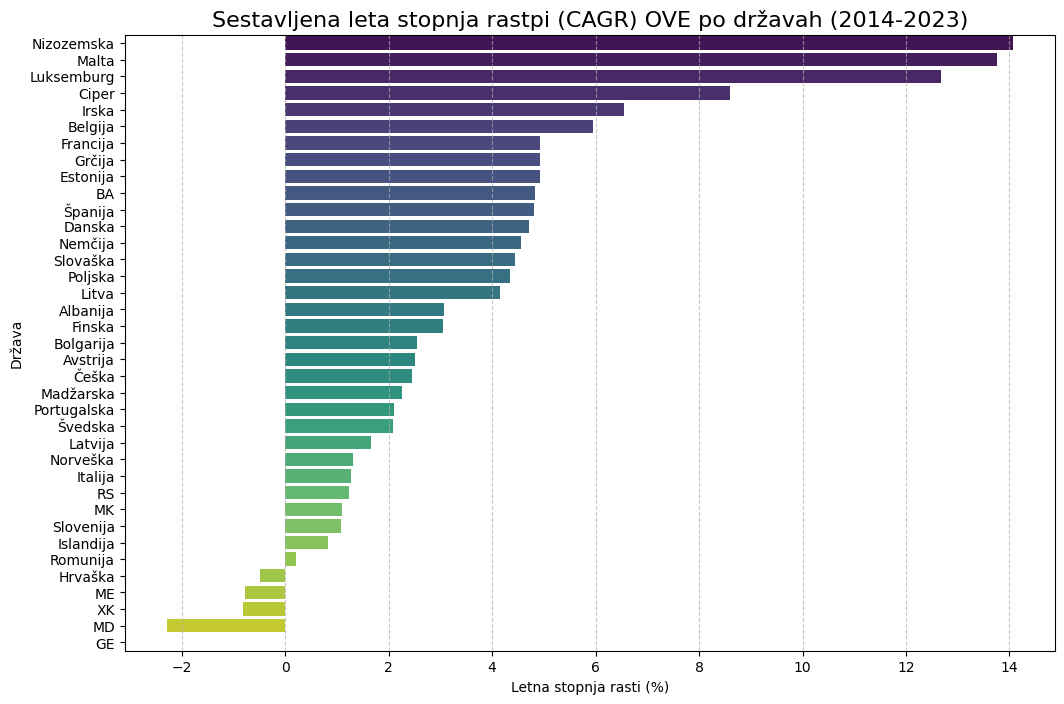

drzava
Nizozemska     14.059712
Malta          13.753199
Luksemburg     12.671785
Ciper           8.588663
Irska           6.552049
Belgija         5.956596
Francija        4.925624
Grčija          4.924972
Estonija        4.918053
BA              4.822295
Španija         4.816611
Danska          4.714609
Nemčija         4.565671
Slovaška        4.443603
Poljska         4.352829
Litva           4.143858
Albanija        3.071758
Finska          3.040494
Bolgarija       2.546252
Avstrija        2.500994
Češka           2.454761
Madžarska       2.251760
Portugalska     2.098512
Švedska         2.080397
Latvija         1.658381
Norveška        1.312297
Italija         1.272775
RS              1.239733
MK              1.095749
Slovenija       1.078013
Islandija       0.829353
Romunija        0.212487
Hrvaška        -0.492492
ME             -0.768961
XK             -0.808574
MD             -2.284638
GE                   NaN
dtype: float64


In [6]:
def izracun_cagr(df_pivot):
    # cagr Izračunamo na podlagi prvega in zadnjega leta v pivot tabeli
    df_prvo = df_pivot.columns[0]
    df_zadnje = df_pivot.columns[-1]
    n_let = df_zadnje - df_prvo

    cagr = ((df_pivot[df_zadnje] /df_pivot[df_prvo])** (1/n_let) - 1)
    return cagr *100

#CAGR za vse države
cagr_s = izracun_cagr(pivot_df).sort_values(ascending=False)

#Vizualizacija 
plt.figure(figsize=(12, 8))
sns.barplot(x=cagr_s, y=cagr_s.index, palette='viridis')
plt.title("Sestavljena leta stopnja rastpi (CAGR) OVE po državah (2014-2023)", fontsize=16)
plt.xlabel("Letna stopnja rasti (%)")
plt.ylabel("Država")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(cagr_s)

Ugotoviti želimo ali imajo bogatejše države kakšno prednost pred revnejšimi in si lahko tako privoščijo hitrejši prehod.

Loaded sdg_08_10_tabular in 0.016s - 2106 rows


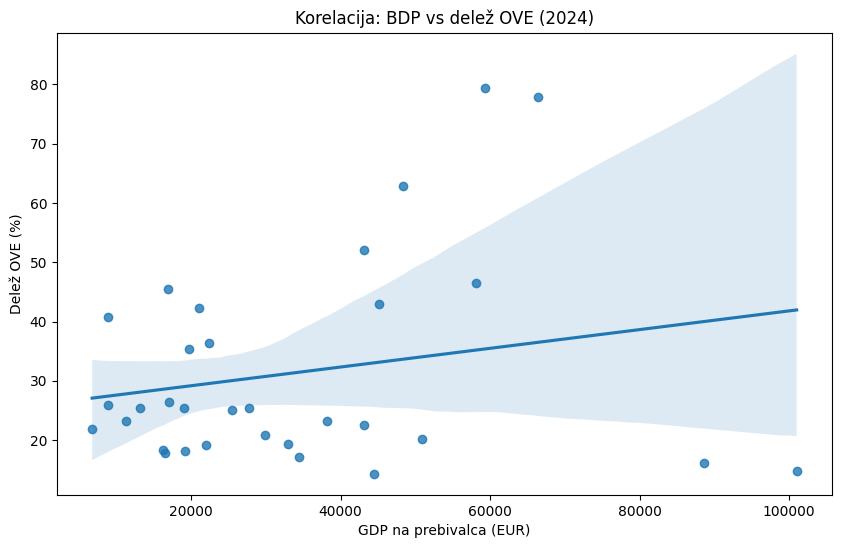

Pearsonov korelacijski koeficient: 0.21


In [7]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Uvoz in dodajanje imen
df_gdp_raw = load_tsv("sdg_08_10_tabular", "data")
df_gdp = add_country_names(df_gdp_raw)

zadnje_leto = pivot_df.columns[-1]


df_gdp_fix = df_gdp[
    (df_gdp["unit"].str.contains("CLV", na=False)) & 
    (df_gdp["unit"].str.contains("EUR_HAB", na=False)) &
    (df_gdp["year"] == zadnje_leto) & 
    (df_gdp["value"] > 1000)
].copy()

#Združevanje
analiza_df = pd.DataFrame({
    "OVE_delez": pivot_df[zadnje_leto],
    "CAGR": cagr_s
}).merge(df_gdp_fix[['drzava', 'value']], left_index=True, right_on='drzava')

analiza_df.rename(columns={'value': 'GDP_per_capita'}, inplace=True)

# ćiščenje praznih vrednosti
analiza_clean = analiza_df.copy()
analiza_clean['GDP_per_capita'] = pd.to_numeric(analiza_clean['GDP_per_capita'], errors='coerce')
analiza_clean['OVE_delez'] = pd.to_numeric(analiza_clean['OVE_delez'], errors='coerce')

# odstranimo vrednosti kjer ni obeh podatkov
analiza_clean = analiza_clean.dropna(subset=['GDP_per_capita', 'OVE_delez'])

#Regresija
if not analiza_clean.empty:
    X = analiza_clean[['GDP_per_capita']].values
    y = analiza_clean['OVE_delez'].values
    
    model = LinearRegression().fit(X, y)
    analiza_clean["ostanek"] = y - model.predict(X)
    
    
    plt.figure(figsize=(10, 6))
    sns.regplot(data=analiza_clean, x="GDP_per_capita", y="OVE_delez")
    plt.title(f"Korelacija: BDP vs delež OVE ({zadnje_leto})")
    plt.xlabel("GDP na prebivalca (EUR)")
    plt.ylabel("Delež OVE (%)")
    plt.show()
    
    korelacija = analiza_clean['GDP_per_capita'].corr(analiza_clean['OVE_delez'])
    print(f"Pearsonov korelacijski koeficient: {korelacija:.2f}")



najti moramo države ki najbolj izstopajo iz povprečja, torej imajo ali zelo visok OVE in nizek BDP ali pa obratno


In [8]:
from sklearn.linear_model import LinearRegression

analiza_clean = analiza_df.dropna(subset=['GDP_per_capita', 'OVE_delez']).copy()

X = analiza_clean[['GDP_per_capita']].values
y = analiza_clean['OVE_delez'].values

model = LinearRegression().fit(X,y)
napoved = model.predict(X)
analiza_clean['ostanek'] = y- napoved

#top 3 odkloni gor in dol
pozitivni_odkl = analiza_clean.sort_values(by='ostanek', ascending=False).head(3)
negativni_odkl = analiza_clean.sort_values(by='ostanek', ascending=True).head(3)

print("Države ki presegajo pričakkovana glede na BDP:")
print(pozitivni_odkl[["drzava", "OVE_delez", "GDP_per_capita"]])

print("\nDržave ki zaostajajo glede na BDP:")
print(negativni_odkl[["drzava", "OVE_delez", "GDP_per_capita"]])

Države ki presegajo pričakkovana glede na BDP:
         drzava  OVE_delez  GDP_per_capita
1966  Islandija     79.332         59270.0
1975   Norveška     77.932         66460.0
1980    Švedska     62.846         48310.0

Države ki zaostajajo glede na BDP:
          drzava  OVE_delez  GDP_per_capita
1969  Luksemburg     14.742        101000.0
1965       Irska     16.064         88600.0
1947     Belgija     14.336         44440.0


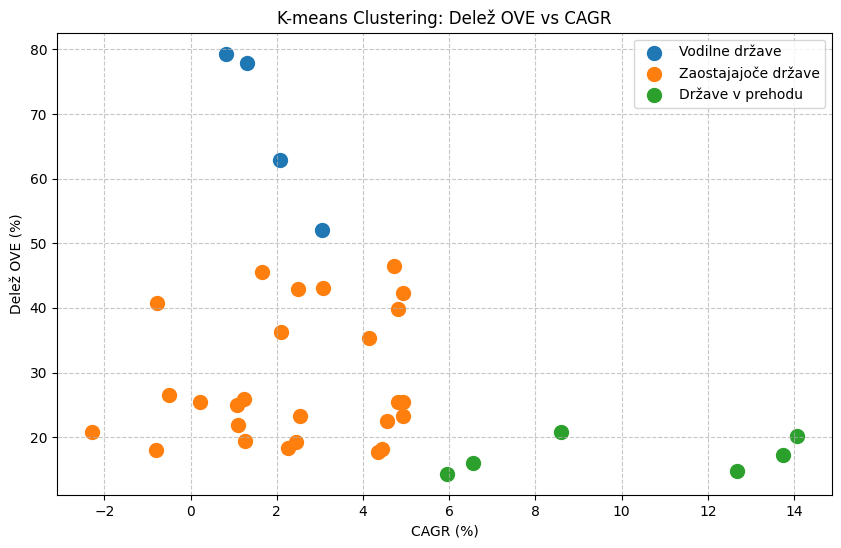


Povprečne vrednosti OVE in CAGR po clusterjih:

Vodilne države:
  Povprečen OVE: 68.06%
  Povprečen CAGR: 1.82%
  Države: ['Islandija', 'Norveška', 'Švedska', 'Finska']

Zaostajajoče države:
  Povprečen OVE: 28.78%
  Povprečen CAGR: 2.45%
  Države: ['Danska', 'Latvija', 'Albanija', 'Avstrija', 'Estonija', 'ME', 'BA', 'Portugalska', 'Litva', 'Hrvaška', 'RS', 'Španija', 'Romunija', 'Grčija', 'Slovenija', 'Francija', 'Bolgarija', 'Nemčija', 'MK', 'MD', 'Italija', 'Češka', 'Madžarska', 'Slovaška', 'XK', 'Poljska']

Države v prehodu:
  Povprečen OVE: 17.23%
  Povprečen CAGR: 10.26%
  Države: ['Ciper', 'Nizozemska', 'Malta', 'Irska', 'Luksemburg', 'Belgija']


In [38]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Izračun CAGR za vse države
cagr_s = izracun_cagr(pivot_df)

# Priprava podatkov za clustering
df_cluster = pd.DataFrame({
    'drzava': pivot_df.index,
    'OVE': pivot_df.iloc[:, -1],
    'CAGR': cagr_s
}).dropna()



# Standardizacija podatkov
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[['OVE', 'CAGR']])

# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Povzetek po clusterjih
cluster_summary = df_cluster.groupby('cluster')[['OVE', 'CAGR']].mean().sort_index()

# Dodelitev imen clusterjem
cluster_imena = {
    2: 'Vodilne države',
    1: 'Države v prehodu',
    0: 'Zaostajajoče države'
}

df_cluster['ime_skupine'] = df_cluster['cluster'].map(cluster_imena)


#Vizualizacija clusterjev

plt.figure(figsize=(10, 6))

for ime in df_cluster['ime_skupine'].unique():
    subset = df_cluster[df_cluster['ime_skupine'] == ime]
    plt.scatter(subset['CAGR'], subset['OVE'], label=ime, s=100)

plt.title('K-means Clustering: Delež OVE vs CAGR')
plt.xlabel('CAGR (%)')
plt.ylabel('Delež OVE (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# Povprečne vrednosti OVE in CAGR po clusterjih
print("\nPovprečne vrednosti OVE in CAGR po clusterjih:")

for name in df_cluster['ime_skupine'].unique():
    subset = df_cluster[df_cluster['ime_skupine'] == name]
    
    mean_ove = subset['OVE'].mean()
    mean_cagr = subset['CAGR'].mean()
    
    print(f"\n{name}:")
    print(f"  Povprečen OVE: {mean_ove:.2f}%")
    print(f"  Povprečen CAGR: {mean_cagr:.2f}%")
    print(f"  Države: {subset['drzava'].tolist()}")
    